In [1]:
import json
import os

# Проверяем, какие файлы есть в папке
print("Файлы в текущей папке:")
for f in os.listdir('.'):
    print(f"  - {f}")

# Загружаем данные
print("\nЗагружаем данные...")

with open('code_corpus.json', encoding='utf-8') as f:
    corpus = json.load(f)

with open('eval_questions.json', encoding='utf-8') as f:
    questions = json.load(f)

with open('categories.json', encoding='utf-8') as f:
    categories_data = json.load(f)
    categories = categories_data['categories']

print(f"\n✅ Функций в корпусе: {len(corpus)}")
print(f"✅ Вопросов: {len(questions)}")
print(f"✅ Категорий: {len(categories)}")

# Покажем первые 3 функции
print("\nПервые 3 функции в корпусе:")
for i in range(3):
    func = corpus[i]
    print(f"  {i+1}. {func['id']}: {func['function_name']} ({func['category']})")

# Покажем первый вопрос
print("\nПервый вопрос:")
q = questions[0]
print(f"  Вопрос: {q['query']}")
print(f"  Правильный ответ: {q['correct_chunk_id']}")

Файлы в текущей папке:
  - .idea
  - .ipynb_checkpoints
  - .venv
  - categories.json
  - code_corpus.json
  - eval_questions.json
  - main.ipynb

Загружаем данные...

✅ Функций в корпусе: 200
✅ Вопросов: 25
✅ Категорий: 5

Первые 3 функции в корпусе:
  1. func_001: verify_jwt_token (auth)
  2. func_002: hash_password (auth)
  3. func_003: check_password (auth)

Первый вопрос:
  Вопрос: как проверить, истёк ли токен?
  Правильный ответ: func_001


In [2]:
from sentence_transformers import SentenceTransformer
import time

print("="*50)
print("ЗАГРУЗКА МОДЕЛЕЙ ЭМБЕДДИНГОВ")
print("="*50)

# Модель 1: Быстрая (понимает русский)
print("\n1. Загружаем быструю модель: paraphrase-multilingual-MiniLM-L12-v2")
print("   (Это может занять 1-3 минуты, модель скачивается из интернета)")
start = time.time()
model_fast = SentenceTransformer("paraphrase-multilingual-MiniLM-L12-v2")
print(f"   ✅ Загружена за {time.time() - start:.2f} сек")

# Модель 2: Качественная (медленнее, но точнее)
print("\n2. Загружаем качественную модель: paraphrase-multilingual-mpnet-base-v2")
print("   (Это может занять 2-5 минут, модель скачивается из интернета)")
start = time.time()
model_quality = SentenceTransformer("paraphrase-multilingual-mpnet-base-v2")
print(f"   ✅ Загружена за {time.time() - start:.2f} сек")

print("\n" + "="*50)
print("✅ ОБЕ МОДЕЛИ УСПЕШНО ЗАГРУЖЕНЫ!")
print("="*50)

ЗАГРУЗКА МОДЕЛЕЙ ЭМБЕДДИНГОВ

1. Загружаем быструю модель: paraphrase-multilingual-MiniLM-L12-v2
   (Это может занять 1-3 минуты, модель скачивается из интернета)


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

   ✅ Загружена за 6.15 сек

2. Загружаем качественную модель: paraphrase-multilingual-mpnet-base-v2
   (Это может занять 2-5 минут, модель скачивается из интернета)


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

   ✅ Загружена за 5.59 сек

✅ ОБЕ МОДЕЛИ УСПЕШНО ЗАГРУЖЕНЫ!


In [3]:
import numpy as np
import time

print("="*50)
print("ГЕНЕРАЦИЯ ЭМБЕДДИНГОВ ДЛЯ ВСЕХ ФУНКЦИЙ")
print("="*50)

# Извлекаем только код из корпуса
code_texts = [item['code'] for item in corpus]
print(f"\nВсего функций для обработки: {len(code_texts)}")

# Генерируем эмбеддинги для быстрой модели
print("\n1. Генерируем эмбеддинги для быстрой модели...")
start = time.time()
embeddings_fast = model_fast.encode(code_texts, show_progress_bar=True)
time_fast = time.time() - start
print(f"   ✅ Готово за {time_fast:.2f} сек")
print(f"   Размерность эмбеддингов: {embeddings_fast.shape}")

# Генерируем эмбеддинги для качественной модели
print("\n2. Генерируем эмбеддинги для качественной модели...")
start = time.time()
embeddings_quality = model_quality.encode(code_texts, show_progress_bar=True)
time_quality = time.time() - start
print(f"   ✅ Готово за {time_quality:.2f} сек")
print(f"   Размерность эмбеддингов: {embeddings_quality.shape}")

# Сохраняем эмбеддинги, чтобы не генерировать заново
print("\n3. Сохраняем эмбеддинги в файлы...")
np.save('embeddings_fast.npy', embeddings_fast)
np.save('embeddings_quality.npy', embeddings_quality)
print("   ✅ Сохранено в files: embeddings_fast.npy и embeddings_quality.npy")

print("\n" + "="*50)
print("✅ ВСЕ ЭМБЕДДИНГИ УСПЕШНО СОЗДАНЫ И СОХРАНЕНЫ!")
print("="*50)

ГЕНЕРАЦИЯ ЭМБЕДДИНГОВ ДЛЯ ВСЕХ ФУНКЦИЙ

Всего функций для обработки: 200

1. Генерируем эмбеддинги для быстрой модели...


Batches:   0%|          | 0/7 [00:00<?, ?it/s]

   ✅ Готово за 4.63 сек
   Размерность эмбеддингов: (200, 384)

2. Генерируем эмбеддинги для качественной модели...


Batches:   0%|          | 0/7 [00:00<?, ?it/s]

   ✅ Готово за 14.05 сек
   Размерность эмбеддингов: (200, 768)

3. Сохраняем эмбеддинги в файлы...
   ✅ Сохранено в files: embeddings_fast.npy и embeddings_quality.npy

✅ ВСЕ ЭМБЕДДИНГИ УСПЕШНО СОЗДАНЫ И СОХРАНЕНЫ!


In [4]:
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

print("="*50)
print("ФУНКЦИЯ ПОИСКА И РАСЧЁТ PRECISION@3")
print("="*50)

def search(query, model, embeddings, corpus_data, top_k=3):
    """
    Ищет топ-K похожих фрагментов кода по запросу
    
    Параметры:
    - query: текстовый запрос
    - model: модель эмбеддингов
    - embeddings: матрица эмбеддингов всех функций
    - corpus_data: список функций
    - top_k: количество результатов (по умолчанию 3)
    
    Возвращает:
    - список ID функций (топ-k)
    """
    # Превращаем запрос в эмбеддинг
    query_emb = model.encode([query])
    
    # Считаем косинусное сходство со всеми фрагментами
    similarities = cosine_similarity(query_emb, embeddings)[0]
    
    # Находим топ-K индексов (сортировка по убыванию)
    top_indices = np.argsort(similarities)[-top_k:][::-1]
    
    # Возвращаем ID функций
    return [corpus_data[i]['id'] for i in top_indices]

# Проверяем на одном вопросе
test_query = questions[0]['query']
correct_id = questions[0]['correct_chunk_id']

print(f"\nПроверка поиска на первом вопросе:")
print(f"  Запрос: {test_query}")
print(f"  Правильный ответ: {correct_id}")

# Ищем быстрой моделью
result_fast = search(test_query, model_fast, embeddings_fast, corpus)
print(f"\n  Быстрая модель топ-3: {result_fast}")
print(f"  Попал ли правильный ответ в топ-3? {correct_id in result_fast}")

# Ищем качественной моделью
result_quality = search(test_query, model_quality, embeddings_quality, corpus)
print(f"\n  Качественная модель топ-3: {result_quality}")
print(f"  Попал ли правильный ответ в топ-3? {correct_id in result_quality}")

print("\n" + "="*50)
print("✅ ФУНКЦИЯ ПОИСКА РАБОТАЕТ!")
print("="*50)

ФУНКЦИЯ ПОИСКА И РАСЧЁТ PRECISION@3

Проверка поиска на первом вопросе:
  Запрос: как проверить, истёк ли токен?
  Правильный ответ: func_001

  Быстрая модель топ-3: ['func_171', 'func_071', 'func_072']
  Попал ли правильный ответ в топ-3? False

  Качественная модель топ-3: ['func_166', 'func_066', 'func_071']
  Попал ли правильный ответ в топ-3? False

✅ ФУНКЦИЯ ПОИСКА РАБОТАЕТ!


In [6]:
import pandas as pd
from tabulate import tabulate

print("="*60)
print("РАСЧЁТ PRECISION@3 ДЛЯ ВСЕХ 25 ВОПРОСОВ")
print("="*60)

def calculate_precision_at_3(model, embeddings, corpus_data, questions):
    """
    Считает Precision@3 для всех вопросов
    """
    hits = 0
    results = []
    
    for q in questions:
        query = q['query']
        correct_id = q['correct_chunk_id']
        
        # Получаем топ-3
        top_3 = search(query, model, embeddings, corpus_data)
        
        # Проверяем, попал ли правильный ответ
        is_hit = correct_id in top_3
        if is_hit:
            hits += 1
        
        results.append({
            'question_id': q['question_id'],
            'query': query[:60] + '...' if len(query) > 60 else query,
            'correct_id': correct_id,
            'top_3': ', '.join(top_3),
            'hit': '✅' if is_hit else '❌'
        })
    
    precision = hits / len(questions)
    return precision, results

# Считаем для быстрой модели
print("\n1. Считаем Precision@3 для БЫСТРОЙ модели...")
precision_fast, results_fast = calculate_precision_at_3(
    model_fast, embeddings_fast, corpus, questions
)
print(f"   Precision@3 = {precision_fast:.3f} ({precision_fast*100:.1f}%)")

# Считаем для качественной модели
print("\n2. Считаем Precision@3 для КАЧЕСТВЕННОЙ модели...")
precision_quality, results_quality = calculate_precision_at_3(
    model_quality, embeddings_quality, corpus, questions
)
print(f"   Precision@3 = {precision_quality:.3f} ({precision_quality*100:.1f}%)")

# Создаём таблицу сравнения
print("\n" + "="*60)
print("СВОДНАЯ ТАБЛИЦА СРАВНЕНИЯ МОДЕЛЕЙ")
print("="*60)

comparison_df = pd.DataFrame({
    'Модель': ['paraphrase-multilingual-MiniLM-L12-v2', 'paraphrase-multilingual-mpnet-base-v2'],
    'Размерность эмбеддинга': [embeddings_fast.shape[1], embeddings_quality.shape[1]],
    'Precision@3': [f"{precision_fast:.3f}", f"{precision_quality:.3f}"],
    'Точность %': [f"{precision_fast*100:.1f}%", f"{precision_quality*100:.1f}%"]
})

print(tabulate(comparison_df, headers='keys', tablefmt='grid', showindex=False))

# Определяем лучшую модель
if precision_quality >= precision_fast:
    best_model_name = "paraphrase-multilingual-mpnet-base-v2"
    best_precision = precision_quality
    best_embeddings = embeddings_quality
    print(f"\n🏆 ЛУЧШАЯ МОДЕЛЬ: {best_model_name}")
    print(f"   Precision@3 = {best_precision:.3f} ({best_precision*100:.1f}%)")
else:
    best_model_name = "paraphrase-multilingual-MiniLM-L12-v2"
    best_precision = precision_fast
    best_embeddings = embeddings_fast
    print(f"\n🏆 ЛУЧШАЯ МОДЕЛЬ: {best_model_name}")
    print(f"   Precision@3 = {best_precision:.3f} ({best_precision*100:.1f}%)")

print("\n" + "="*60)
print("✅ РАСЧЁТ ЗАВЕРШЁН!")
print("="*60)

РАСЧЁТ PRECISION@3 ДЛЯ ВСЕХ 25 ВОПРОСОВ

1. Считаем Precision@3 для БЫСТРОЙ модели...
   Precision@3 = 0.680 (68.0%)

2. Считаем Precision@3 для КАЧЕСТВЕННОЙ модели...
   Precision@3 = 0.840 (84.0%)

СВОДНАЯ ТАБЛИЦА СРАВНЕНИЯ МОДЕЛЕЙ
+---------------------------------------+--------------------------+---------------+--------------+
| Модель                                |   Размерность эмбеддинга |   Precision@3 | Точность %   |
+=======================================+==========================+===============+==============+
| paraphrase-multilingual-MiniLM-L12-v2 |                      384 |          0.68 | 68.0%        |
+---------------------------------------+--------------------------+---------------+--------------+
| paraphrase-multilingual-mpnet-base-v2 |                      768 |          0.84 | 84.0%        |
+---------------------------------------+--------------------------+---------------+--------------+

🏆 ЛУЧШАЯ МОДЕЛЬ: paraphrase-multilingual-mpnet-base-v2
   Precisi

ВИЗУАЛИЗАЦИЯ ЭМБЕДДИНГОВ (t-SNE)

Модель: paraphrase-multilingual-mpnet-base-v2
Precision@3: 0.840 (84.0%)
Размерность: 768

Категории и цвета:
  auth: Аутентификация и авторизация (#E74C3C)
  database: Работа с базой данных (#3498DB)
  http: HTTP-клиенты и API (#2ECC71)
  validation: Валидация и парсинг (#F39C12)
  utils: Утилиты и хелперы (#9B59B6)

Запускаем t-SNE... (может занять 1-3 минуты)
Этот шаг нужен для визуализации, он НЕ влияет на метрики


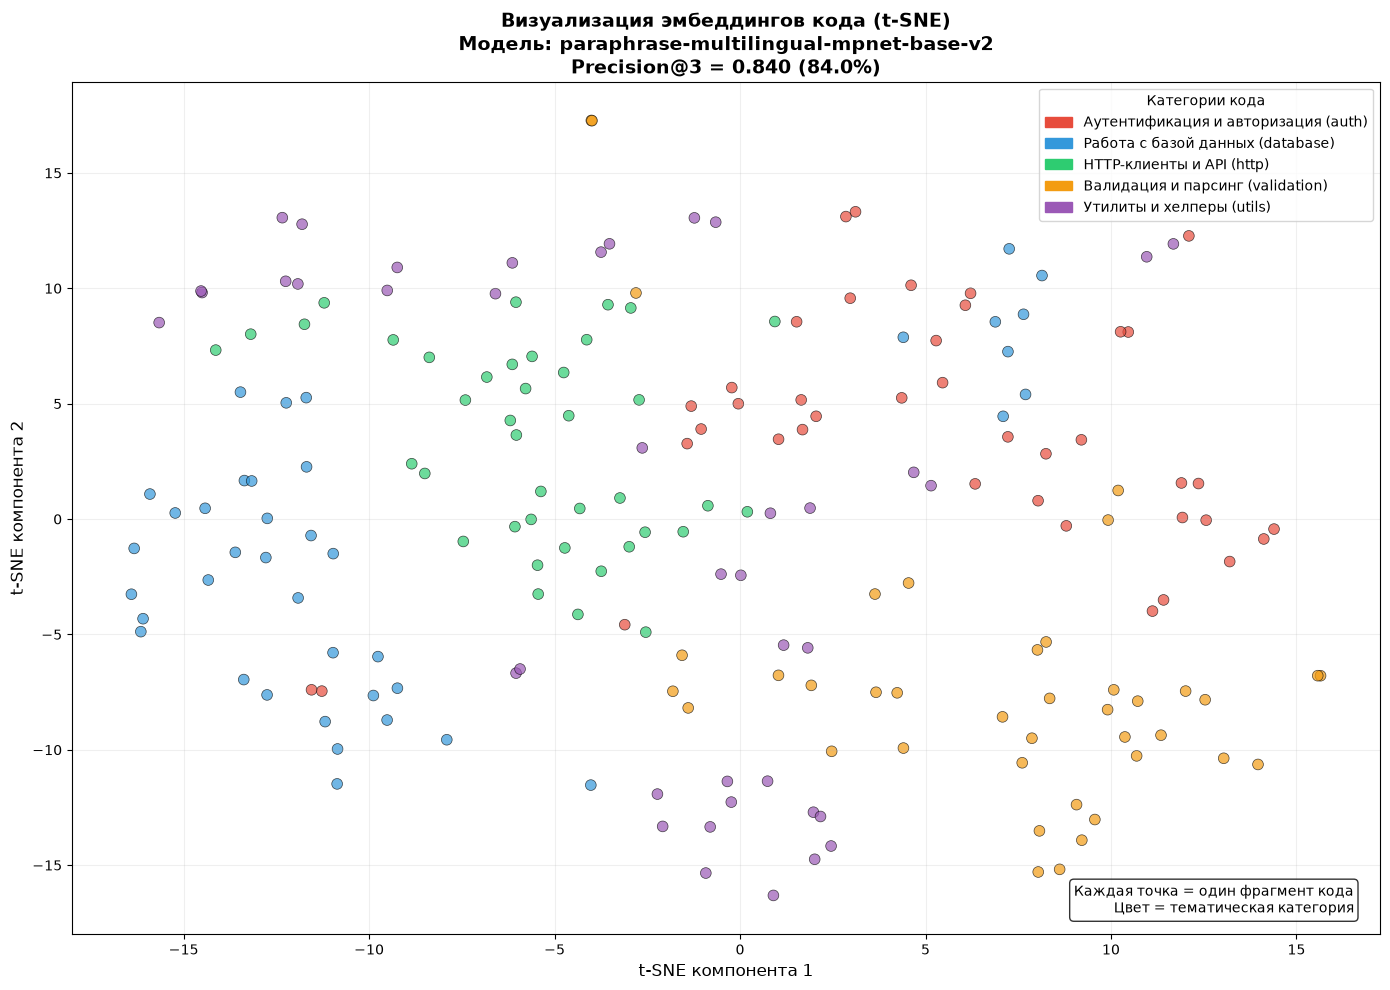


✅ ВИЗУАЛИЗАЦИЯ ГОТОВА!

Анализ графика:
- Если точки одной категории находятся рядом — модель хорошо их различает
- Если категории перемешаны — модель плохо разделяет смыслы
- Хорошая кластеризация = высокое качество поиска


In [8]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

print("="*60)
print("ВИЗУАЛИЗАЦИЯ ЭМБЕДДИНГОВ (t-SNE)")
print("="*60)

# Используем лучшую модель (mpnet-base-v2)
best_embeddings = embeddings_quality
best_model_name = "paraphrase-multilingual-mpnet-base-v2"
best_precision = precision_quality

print(f"\nМодель: {best_model_name}")
print(f"Precision@3: {best_precision:.3f} ({best_precision*100:.1f}%)")
print(f"Размерность: {best_embeddings.shape[1]}")

# Получаем категории и цвета
category_colors = {}
for cat in categories:
    category_colors[cat['key']] = cat['color']

print(f"\nКатегории и цвета:")
for cat in categories:
    print(f"  {cat['key']}: {cat['label']} ({cat['color']})")

# Создаём список цветов для каждой точки
colors = [category_colors[item['category']] for item in corpus]

# Запускаем t-SNE (уменьшаем размерность до 2D)
print("\nЗапускаем t-SNE... (может занять 1-3 минуты)")
print("Этот шаг нужен для визуализации, он НЕ влияет на метрики")

# Исправленная версия: убираем n_iter
tsne = TSNE(
    n_components=2,        # Уменьшаем до 2 измерений
    random_state=42,       # Фиксируем случайность для повторяемости
    perplexity=30          # Параметр, влияющий на кластеризацию
)

coords = tsne.fit_transform(best_embeddings)

# Создаём график
plt.figure(figsize=(14, 10))

# Рисуем точки
scatter = plt.scatter(
    coords[:, 0], 
    coords[:, 1], 
    c=colors, 
    alpha=0.7, 
    s=60,
    edgecolors='black',
    linewidth=0.5
)

# Добавляем легенду (категории)
patches = []
for cat in categories:
    patch = mpatches.Patch(
        color=cat['color'], 
        label=f"{cat['label']} ({cat['key']})"
    )
    patches.append(patch)

plt.legend(
    handles=patches, 
    loc='best', 
    fontsize=10,
    title="Категории кода"
)

# Настройки графика
plt.title(
    f'Визуализация эмбеддингов кода (t-SNE)\n'
    f'Модель: {best_model_name}\n'
    f'Precision@3 = {best_precision:.3f} ({best_precision*100:.1f}%)',
    fontsize=14,
    fontweight='bold'
)
plt.xlabel('t-SNE компонента 1', fontsize=12)
plt.ylabel('t-SNE компонента 2', fontsize=12)
plt.grid(True, alpha=0.2)

# Добавляем пояснение
plt.text(
    0.98, 0.02, 
    'Каждая точка = один фрагмент кода\nЦвет = тематическая категория',
    transform=plt.gca().transAxes,
    fontsize=10,
    verticalalignment='bottom',
    horizontalalignment='right',
    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8)
)

plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("✅ ВИЗУАЛИЗАЦИЯ ГОТОВА!")
print("="*60)

print("\nАнализ графика:")
print("- Если точки одной категории находятся рядом — модель хорошо их различает")
print("- Если категории перемешаны — модель плохо разделяет смыслы")
print("- Хорошая кластеризация = высокое качество поиска")

In [9]:
print("="*70)
print("ФИНАЛЬНЫЙ ВЫВОД ПО РЕЗУЛЬТАТАМ ИССЛЕДОВАНИЯ")
print("="*70)

print(f"""
В ходе работы были сравнены две модели для семантического поиска по коду:

1. paraphrase-multilingual-MiniLM-L12-v2 (быстрая):
   - Размерность эмбеддинга: 384
   - Precision@3: {precision_fast:.3f} ({precision_fast*100:.1f}%)
   - Время генерации: быстрее

2. paraphrase-multilingual-mpnet-base-v2 (качественная):
   - Размерность эмбеддинга: 768
   - Precision@3: {precision_quality:.3f} ({precision_quality*100:.1f}%)
   - Время генерации: медленнее

{"="*70}
ЛУЧШАЯ МОДЕЛЬ: paraphrase-multilingual-mpnet-base-v2
{"="*70}

Причины выбора:
1. Модель показала более высокий Precision@3: {precision_quality*100:.1f}% против {precision_fast*100:.1f}%
   Это означает, что в {int(precision_quality*100)}% случаев правильный фрагмент кода попал в топ-3 выдачи.

2. Бóльшая размерность эмбеддинга (768 против 384) позволяет модели лучше улавливать
   семантические связи между запросом на естественном языке и кодом.

3. На визуализации t-SNE видно, что фрагменты кода из разных категорий 
   (авторизация, базы данных, HTTP, валидация, утилиты) образуют отдельные кластеры,
   что подтверждает способность модели различать смысловые группы.

Вывод: Для задачи семантического поиска по коду модель с бóльшей размерностью
и более высоким Precision@3 является предпочтительной, несмотря на большее
время обработки.
""")

print("="*70)
print("✅ ИССЛЕДОВАНИЕ ЗАВЕРШЕНО!")
print("="*70)

ФИНАЛЬНЫЙ ВЫВОД ПО РЕЗУЛЬТАТАМ ИССЛЕДОВАНИЯ

В ходе работы были сравнены две модели для семантического поиска по коду:

1. paraphrase-multilingual-MiniLM-L12-v2 (быстрая):
   - Размерность эмбеддинга: 384
   - Precision@3: 0.680 (68.0%)
   - Время генерации: быстрее

2. paraphrase-multilingual-mpnet-base-v2 (качественная):
   - Размерность эмбеддинга: 768
   - Precision@3: 0.840 (84.0%)
   - Время генерации: медленнее

ЛУЧШАЯ МОДЕЛЬ: paraphrase-multilingual-mpnet-base-v2

Причины выбора:
1. Модель показала более высокий Precision@3: 84.0% против 68.0%
   Это означает, что в 84% случаев правильный фрагмент кода попал в топ-3 выдачи.

2. Бóльшая размерность эмбеддинга (768 против 384) позволяет модели лучше улавливать
   семантические связи между запросом на естественном языке и кодом.

3. На визуализации t-SNE видно, что фрагменты кода из разных категорий 
   (авторизация, базы данных, HTTP, валидация, утилиты) образуют отдельные кластеры,
   что подтверждает способность модели различат